# Sleep Monitor Analysis — Raw Data
Reads directly from the CSV.GZ files in `overnight_6subject_pelthupdate_030526`.
No MATLAB dependency. Sleep stage annotations are extracted from the EDF+ files when present.

**CSV columns:** `timeSM, timeMS, CH, CLE, CRE, aX, aY, aZ, EEG, EOGl, EOGr, ECG, Flow, Pleth, Thorax, Abdomen`  
**Fs:** 100 Hz  •  **Sessions:** 12 (6 subjects × 2 nights)

## Section 1 — Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from scipy.signal import butter, filtfilt, spectrogram, welch
from scipy.interpolate import interp1d
from scipy.ndimage import uniform_filter1d
import gzip
from pathlib import Path

%matplotlib inline
plt.rcParams.update({'figure.dpi': 120, 'axes.grid': True, 'grid.alpha': 0.3, 'font.size': 9})

In [2]:
BASE_DIR = Path(r'C:\Users\adity\Documents\sleep monitor\overnight_6subject_pelthupdate_030526\overnight_6subject_pelthupdate_030526')

CAP_CHANNELS   = ['CH', 'CLE', 'CRE', 'aX', 'aY', 'aZ']
PSG_CHANNELS   = ['EEG', 'EOGl', 'EOGr', 'ECG', 'Flow', 'Pleth', 'Thorax', 'Abdomen']
ALL_SIG_COLS   = CAP_CHANNELS + PSG_CHANNELS
FS             = 100.0  # Hz (confirmed from timeMS step = 10 ms)

EEG_BANDS   = {'delta': (0.5, 4.0), 'theta': (4.0, 8.0), 'alpha': (8.0, 13.0), 'beta': (13.0, 30.0)}
BAND_COLORS = {'delta': '#C0392B', 'theta': '#E67E22', 'alpha': '#27AE60', 'beta': '#2980B9'}

def _subj_dir(subj_id, initials):
    return BASE_DIR / f'{subj_id} - {initials}'

def _session_dir(subj_id, initials, date):
    return _subj_dir(subj_id, initials) / date / f'Sync_{date}'

def _csv_path(subj_id, initials, date, variant=''):
    tag = '_1point_sync' if variant == '1point' else ''
    return _session_dir(subj_id, initials, date) / f'SleepMask_PSG_100Hz{tag}_combined_{date}.csv.gz'

_S = [
    ('OS001','KJK','09-17-2024', ''), ('OS001','KJK','09-18-2024', ''),
    ('OS002','LDI','09-19-2024', ''), ('OS002','LDI','09-20-2024', ''),
    ('OS003','LCW','12-18-2025', ''), ('OS003','LCW','12-19-2025', ''),
    ('OS004','CJH','12-25-2025','1point'), ('OS004','CJH','12-26-2025','1point'),
    ('OS005','CJY','01-03-2026','1point'), ('OS005','CJY','12-27-2025','1point'),
    ('OS006','SK', '01-14-2026', ''),  ('OS006','SK', '01-15-2026', ''),
]

SESSION_META = [
    {
        'idx':      i,
        'subject':  sid,
        'initials': ini,
        'night':    (i % 2) + 1,
        'label':    f'S{(i // 2) + 1}N{(i % 2) + 1}',
        'date':     date,
        'csv':      _csv_path(sid, ini, date, var),
    }
    for i, (sid, ini, date, var) in enumerate(_S)
]

print(f'Session registry built — {len(SESSION_META)} sessions')
for m in SESSION_META:
    csv_ok = '✓' if m['csv'].exists() else '✗'
    print(f"  [{m['idx']:2d}] {m['label']}  {m['subject']}-{m['initials']}  {m['date']}  csv:{csv_ok}")


Session registry built — 12 sessions
  [ 0] S1N1  OS001-KJK  09-17-2024  csv:✓
  [ 1] S1N2  OS001-KJK  09-18-2024  csv:✓
  [ 2] S2N1  OS002-LDI  09-19-2024  csv:✓
  [ 3] S2N2  OS002-LDI  09-20-2024  csv:✓
  [ 4] S3N1  OS003-LCW  12-18-2025  csv:✓
  [ 5] S3N2  OS003-LCW  12-19-2025  csv:✓
  [ 6] S4N1  OS004-CJH  12-25-2025  csv:✓
  [ 7] S4N2  OS004-CJH  12-26-2025  csv:✓
  [ 8] S5N1  OS005-CJY  01-03-2026  csv:✓
  [ 9] S5N2  OS005-CJY  12-27-2025  csv:✓
  [10] S6N1  OS006-SK  01-14-2026  csv:✓
  [11] S6N2  OS006-SK  01-15-2026  csv:✓


## Section 2 — Data Loading

In [3]:
def load_session(idx, dtype=np.float32):
    """
    Load one session from its CSV.GZ file.

    Returns a dict with keys:
      meta     : SESSION_META[idx]
      time_ms  : (N,) float32 — milliseconds from start
      time_hr  : (N,) float32 — hours from start
      cap      : dict {channel -> (N,) array}  CH, CLE, CRE, aX, aY, aZ, acc_mag
      psg      : dict {channel -> (N,) array}  EEG, EOGl, EOGr, ECG, Flow, Pleth, Thorax, Abdomen
      fs       : float  (100.0 Hz)
    """
    meta = SESSION_META[idx]

    df = pd.read_csv(meta['csv'], compression='gzip', dtype={
        col: np.float32 for col in ALL_SIG_COLS + ['timeMS']
    }, usecols=['timeMS'] + ALL_SIG_COLS)

    t_ms  = df['timeMS'].to_numpy(dtype=dtype)
    t_ms -= t_ms[0]
    t_hr  = t_ms / 3_600_000.0

    cap = {ch: df[ch].to_numpy(dtype=dtype) for ch in CAP_CHANNELS}
    aX, aY, aZ = cap['aX'], cap['aY'], cap['aZ']
    cap['acc_mag'] = np.sqrt(aX**2 + aY**2 + aZ**2).astype(dtype)
    psg = {ch: df[ch].to_numpy(dtype=dtype) for ch in PSG_CHANNELS}

    return {
        'meta':    meta,
        'time_ms': t_ms,
        'time_hr': t_hr,
        'cap':     cap,
        'psg':     psg,
        'fs':      FS,
    }


In [4]:
# Load all 12 sessions
# Each session is ~300-400 MB as float32; total ~4-5 GB — may be slow on low-RAM machines.
# To load only a subset: sessions = [load_session(i) for i in [0, 1, 2]]

sessions = []
for i in range(12):
    print(f'Loading session {i} ({SESSION_META[i]["label"]})...', end=' ', flush=True)
    s = load_session(i)
    dur = s['time_hr'][-1]
    print(f'{dur:.2f} hr, {len(s["time_hr"]):,} samples')
    sessions.append(s)

print('\nAll sessions loaded.')


Loading session 0 (S1N1)... 7.95 hr, 2,862,001 samples
Loading session 1 (S1N2)... 7.63 hr, 2,748,001 samples
Loading session 2 (S2N1)... 7.73 hr, 2,784,001 samples
Loading session 3 (S2N2)... 6.77 hr, 2,436,001 samples
Loading session 4 (S3N1)... 6.93 hr, 2,496,001 samples
Loading session 5 (S3N2)... 8.66 hr, 3,117,001 samples
Loading session 6 (S4N1)... 6.18 hr, 2,224,400 samples
Loading session 7 (S4N2)... 6.02 hr, 2,166,001 samples
Loading session 8 (S5N1)... 4.11 hr, 1,479,001 samples
Loading session 9 (S5N2)... 4.74 hr, 1,707,001 samples
Loading session 10 (S6N1)... 5.16 hr, 1,857,001 samples
Loading session 11 (S6N2)... 5.78 hr, 2,082,001 samples

All sessions loaded.


## Section 3 — Helper Functions

In [5]:
def butter_bandpass(data, f_low, f_high, fs=FS, order=3):
    nyq = fs / 2.0
    if f_high >= nyq:
        raise ValueError(f'f_high={f_high} >= Nyquist={nyq}')
    b, a = butter(order, [f_low / nyq, f_high / nyq], btype='band')
    return filtfilt(b, a, data.astype(np.float64))


def detrend_segment(data, win_sec=10.0, fs=FS):
    """Segment-wise linear detrend + mean removal (mirrors MATLAB detrendMeanFil)."""
    w  = max(1, int(np.ceil(fs * win_sec)))
    x  = data.astype(np.float64)
    out = x.copy()
    idx = np.arange(w, dtype=np.float64)
    for s in range(0, len(x) - w + 1, w):
        seg = x[s:s + w]
        c   = np.polyfit(idx, seg, 1)
        seg_dt = seg - np.polyval(c, idx)
        out[s:s + w] = seg_dt - seg_dt.mean()
    return out


def outlier_clip(data, win_size=1000, threshold=7.0):
    x     = data.astype(np.float64)
    trend = uniform_filter1d(x, size=int(win_size))
    res   = x - trend
    bad   = np.abs(res) > threshold * np.std(res)
    clean = x.copy(); clean[bad] = np.nan
    nans  = np.isnan(clean)
    if nans.any() and (~nans).sum() >= 2:
        fi = interp1d(np.where(~nans)[0], clean[~nans], kind='linear', fill_value='extrapolate')
        clean[nans] = fi(np.where(nans)[0])
    return clean


def compute_band_powers(eeg, fs, t_ep, epoch_sec=30.0):
    spe    = int(np.round(epoch_sec * fs))
    n_ep   = len(t_ep)
    powers = {b: np.full(n_ep, np.nan) for b in EEG_BANDS}
    for k in range(n_ep):
        seg = eeg[k * spe:(k + 1) * spe]
        if len(seg) < spe:
            break
        f_w, psd = welch(seg, fs=fs, nperseg=min(256, len(seg)))
        for band, (flo, fhi) in EEG_BANDS.items():
            m = (f_w >= flo) & (f_w <= fhi)
            if m.any():
                powers[band][k] = np.trapz(psd[m], f_w[m])
    return powers


## Section 4 — Exploratory Overview

In [6]:
rows = []
for s in sessions:
    m = s['meta']
    t = s['time_hr']
    rows.append({
        'Label':         m['label'],
        'Subject':       m['subject'],
        'Initials':      m['initials'],
        'Night':         m['night'],
        'Date':          m['date'],
        'Duration (hr)': round(float(t[-1]), 2),
        'Samples':       len(t),
        'Fs (Hz)':       s['fs'],
    })

df_overview = pd.DataFrame(rows)
display(df_overview)


,Label,Subject,Initials,Night,Date,Duration (hr),Samples,Fs (Hz)
0,S1N1,OS001,KJK,1,09-17-2024,7.95,2862001,100.0
1,S1N2,OS001,KJK,2,09-18-2024,7.63,2748001,100.0
2,S2N1,OS002,LDI,1,09-19-2024,7.73,2784001,100.0
3,S2N2,OS002,LDI,2,09-20-2024,6.77,2436001,100.0
4,S3N1,OS003,LCW,1,12-18-2025,6.93,2496001,100.0
5,S3N2,OS003,LCW,2,12-19-2025,8.66,3117001,100.0
6,S4N1,OS004,CJH,1,12-25-2025,6.18,2224400,100.0
7,S4N2,OS004,CJH,2,12-26-2025,6.02,2166001,100.0
8,S5N1,OS005,CJY,1,01-03-2026,4.11,1479001,100.0
9,S5N2,OS005,CJY,2,12-27-2025,4.74,1707001,100.0


## Section 5 — Single-Session Time Series

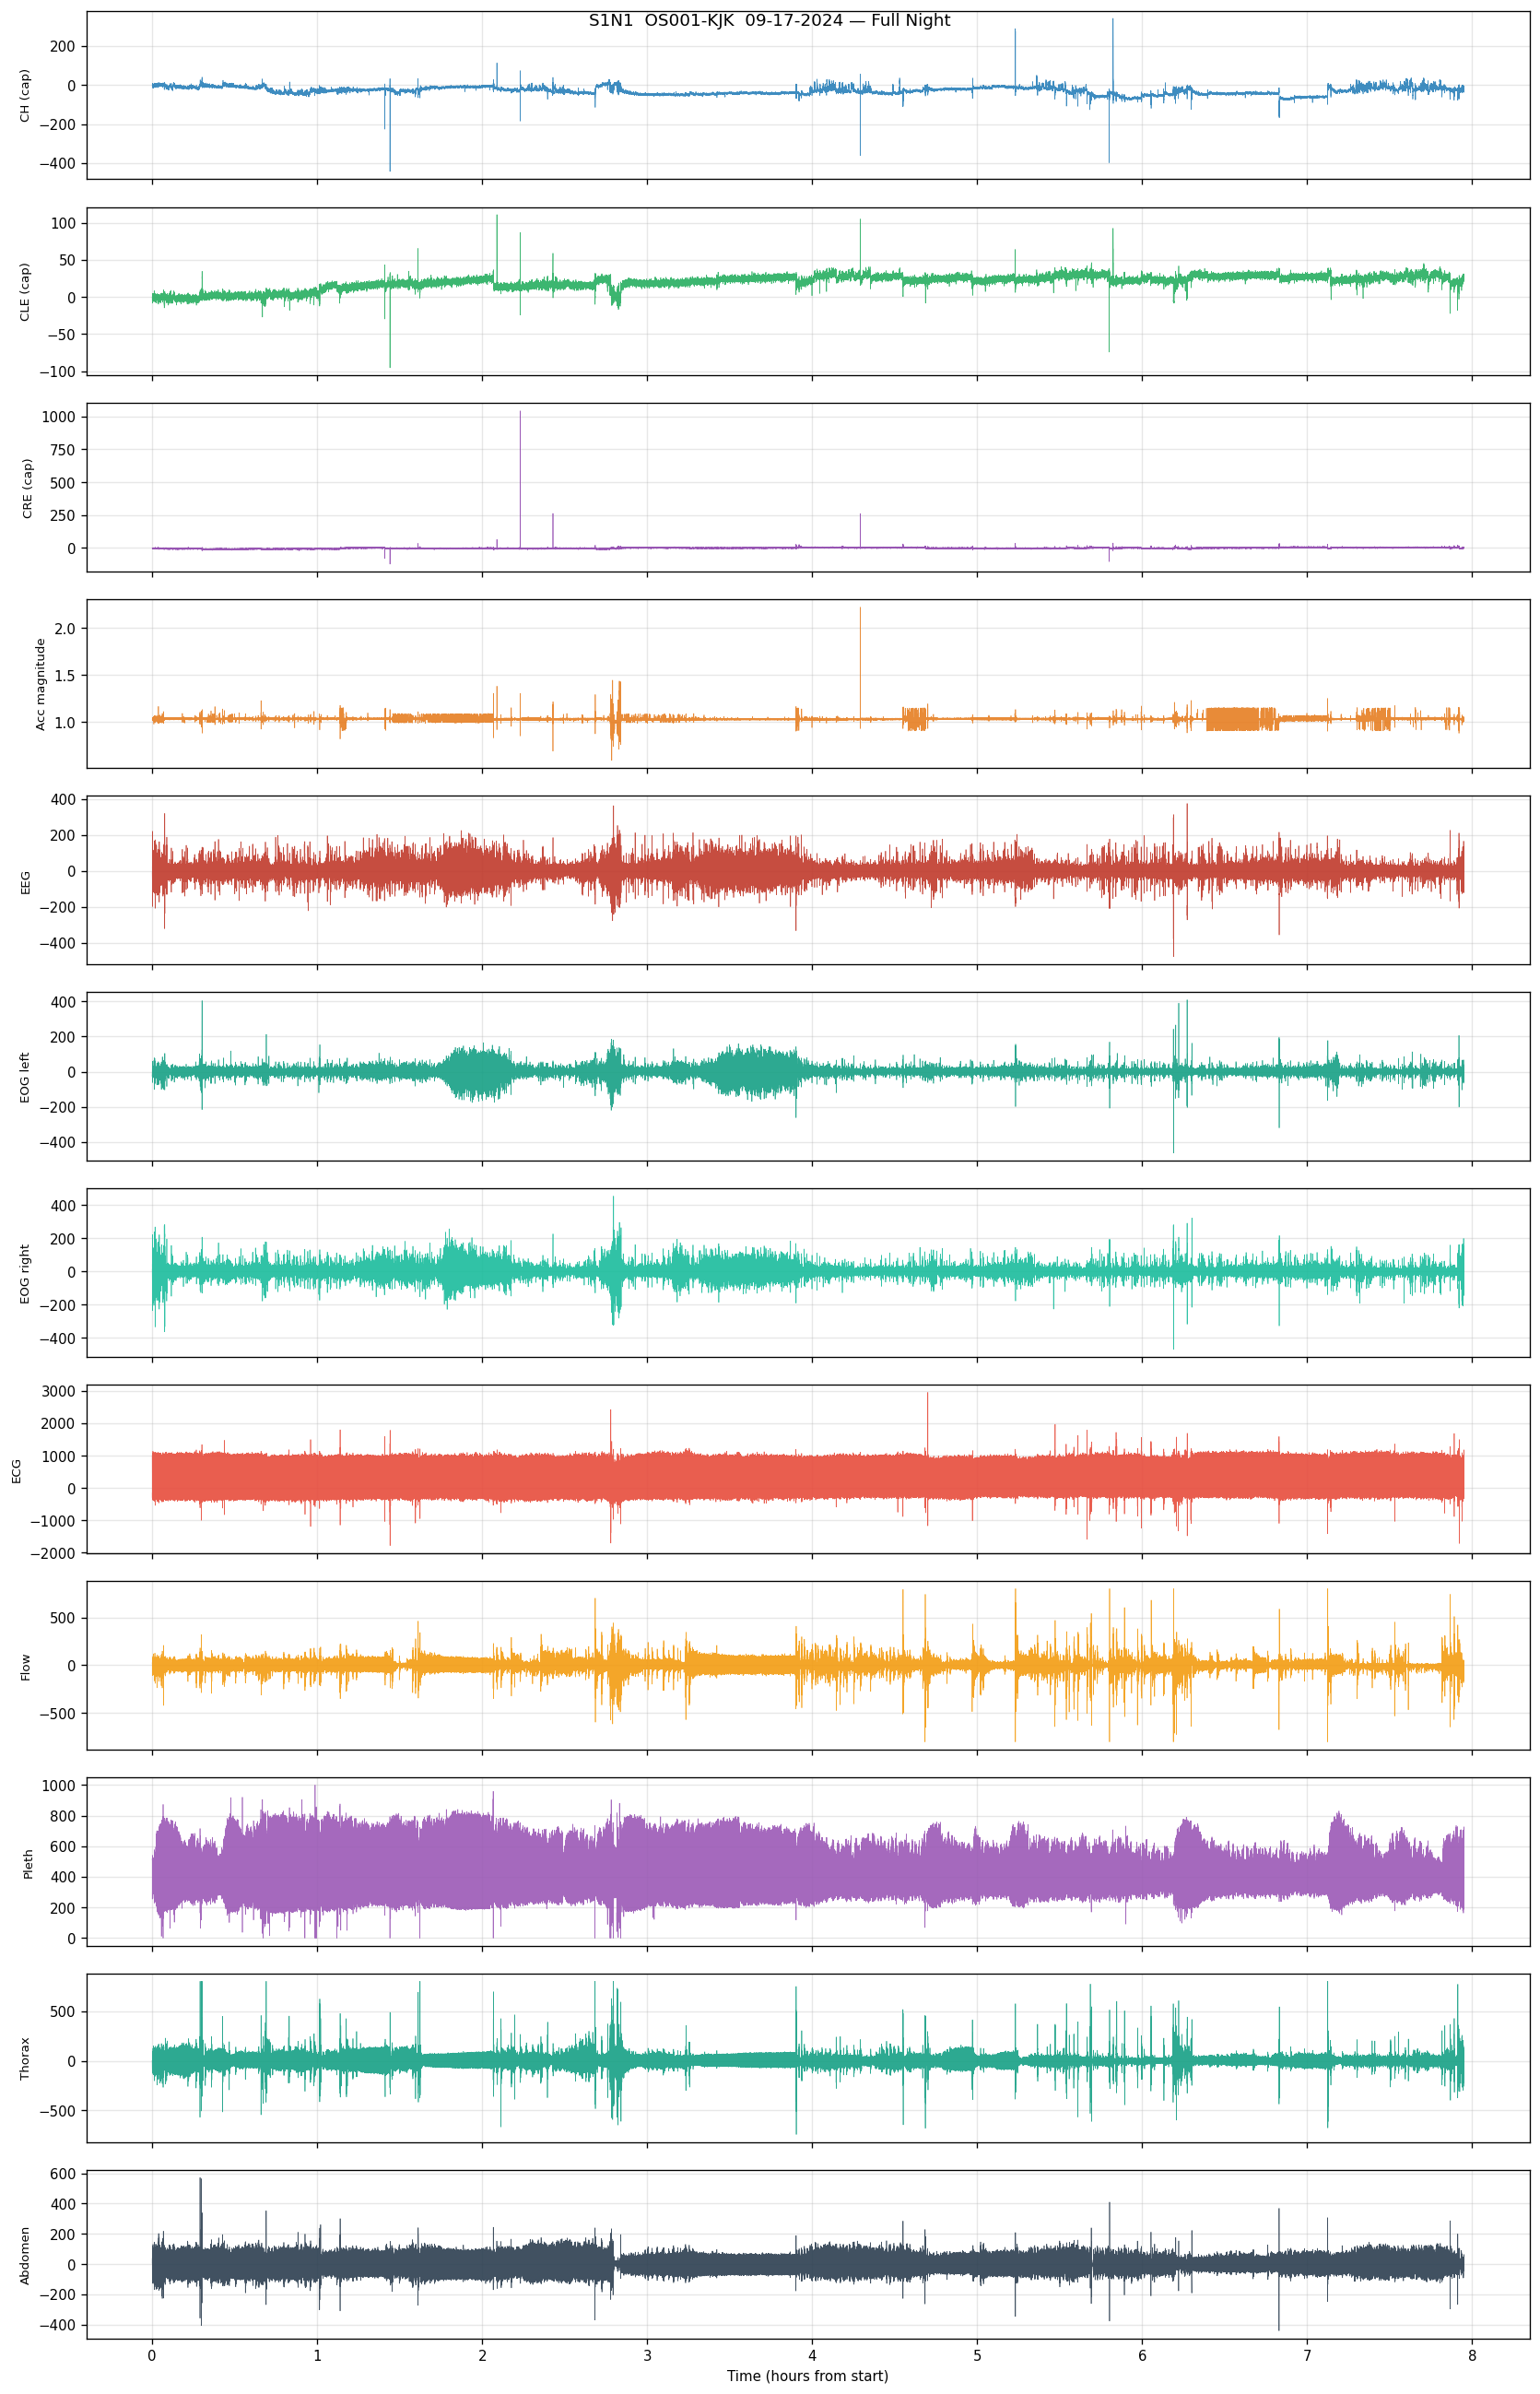

In [7]:
SESSION = 0   # Change (0–11) to inspect a different session

s    = sessions[SESSION]
t    = s['time_hr']
cap  = s['cap']
psg  = s['psg']

# Baseline-correct cap channels
CH   = cap['CH']  - cap['CH'][0]
CLE  = cap['CLE'] - cap['CLE'][0]
CRE  = cap['CRE'] - cap['CRE'][0]

panels = [
    ('CH (cap)',       t, CH,              '#2980B9'),
    ('CLE (cap)',      t, CLE,             '#27AE60'),
    ('CRE (cap)',      t, CRE,             '#8E44AD'),
    ('Acc magnitude',  t, cap['acc_mag'],  '#E67E22'),
    ('EEG',            t, psg['EEG'],      '#C0392B'),
    ('EOG left',       t, psg['EOGl'],     '#16A085'),
    ('EOG right',      t, psg['EOGr'],     '#1ABC9C'),
    ('ECG',            t, psg['ECG'],      '#E74C3C'),
    ('Flow',           t, psg['Flow'],     '#F39C12'),
    ('Pleth',          t, psg['Pleth'],    '#9B59B6'),
    ('Thorax',         t, psg['Thorax'],   '#16A085'),
    ('Abdomen',        t, psg['Abdomen'],  '#2C3E50'),
]

fig, axes = plt.subplots(len(panels), 1, figsize=(14, 22), sharex=True)
for ax, (label, t_, sig, color) in zip(axes, panels):
    ax.plot(t_, sig, color=color, lw=0.4, alpha=0.9)
    ax.set_ylabel(label, fontsize=8)

axes[-1].set_xlabel('Time (hours from start)')
m = s['meta']
fig.suptitle(f"{m['label']}  {m['subject']}-{m['initials']}  {m['date']} — Full Night", fontsize=11)
plt.tight_layout()
plt.show()


## Section 6 — Signal Processing

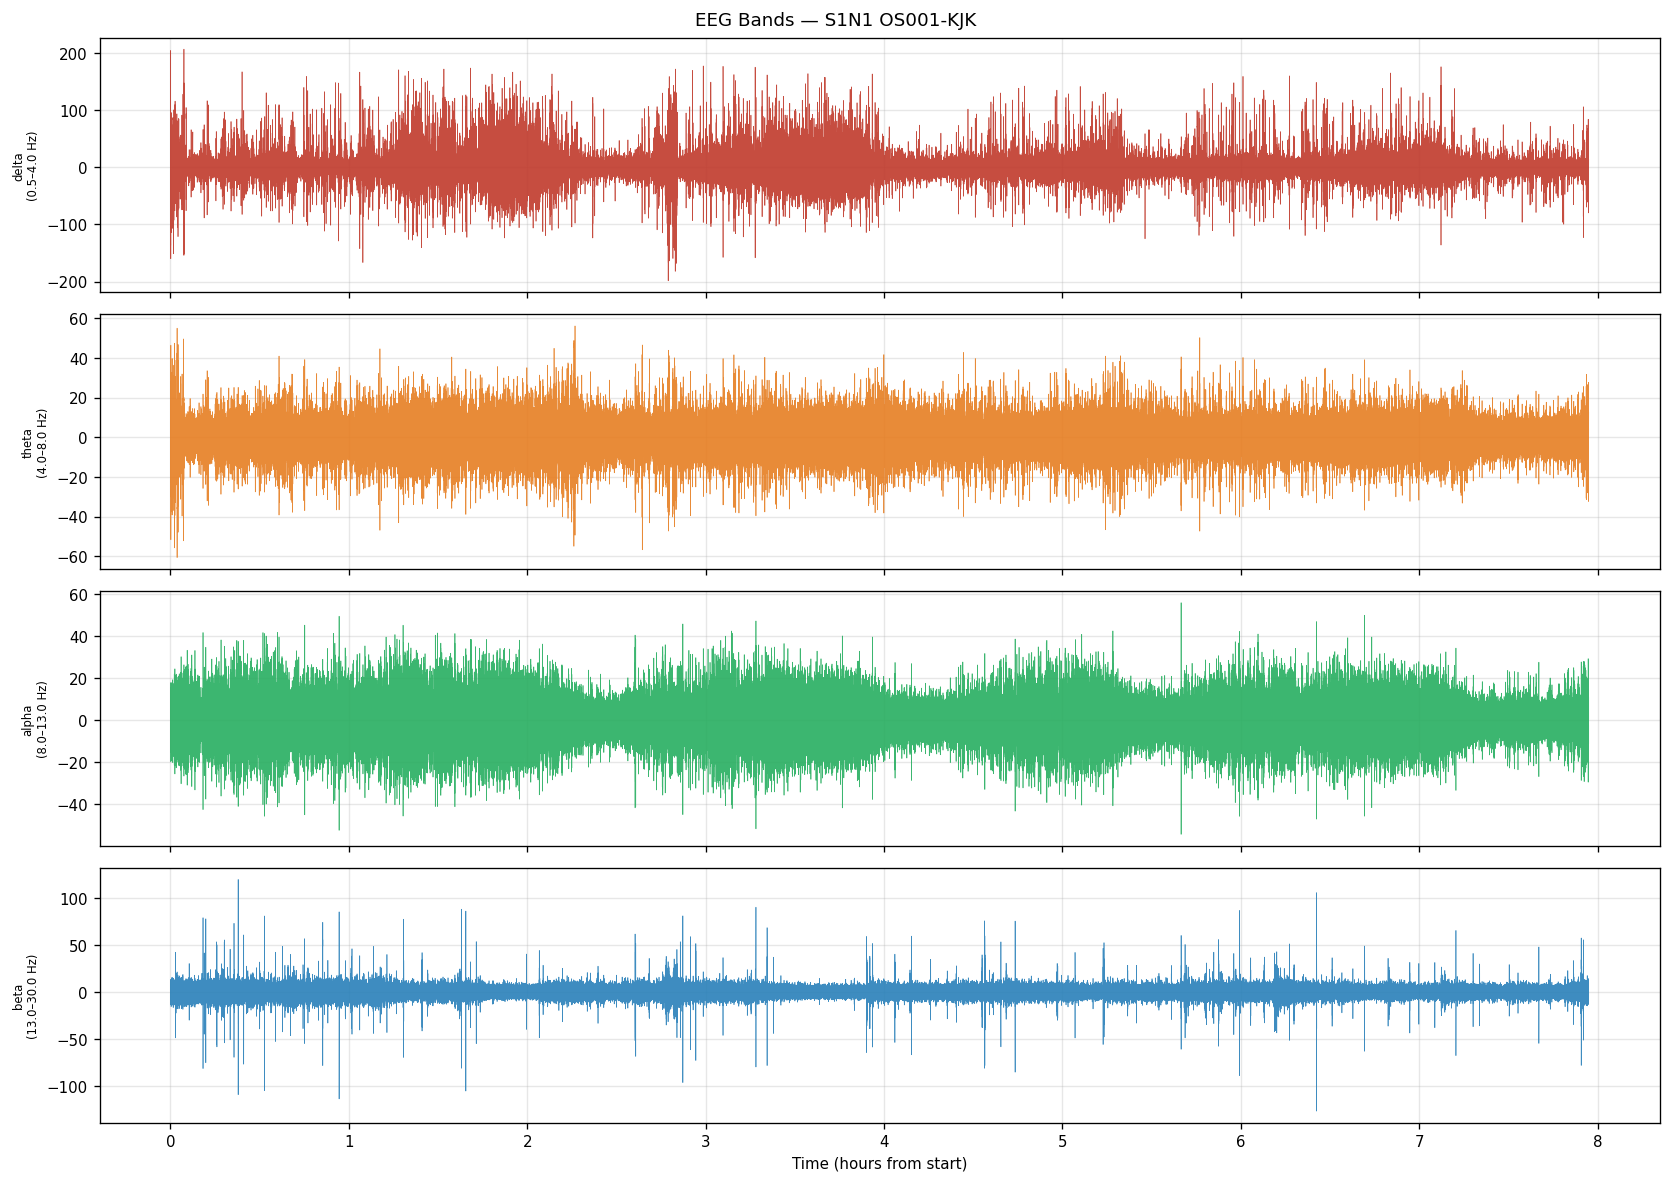

In [8]:
# EEG band-filtered time series
s   = sessions[SESSION]
t   = s['time_hr']
eeg = s['psg']['EEG'].astype(np.float64)

fig, axes = plt.subplots(len(EEG_BANDS), 1, figsize=(14, 10), sharex=True)

for ax, (band, (flo, fhi)) in zip(axes, EEG_BANDS.items()):
    try:
        filtered = butter_bandpass(eeg, flo, fhi)
        ax.plot(t, filtered, color=BAND_COLORS[band], lw=0.4, alpha=0.9)
    except ValueError as e:
        ax.text(0.5, 0.5, str(e), transform=ax.transAxes, ha='center', color='red')
    ax.set_ylabel(f'{band}\n({flo}–{fhi} Hz)', fontsize=7)

axes[-1].set_xlabel('Time (hours from start)')
m = s['meta']
fig.suptitle(f"EEG Bands — {m['label']} {m['subject']}-{m['initials']}", fontsize=11)
plt.tight_layout(); plt.show()


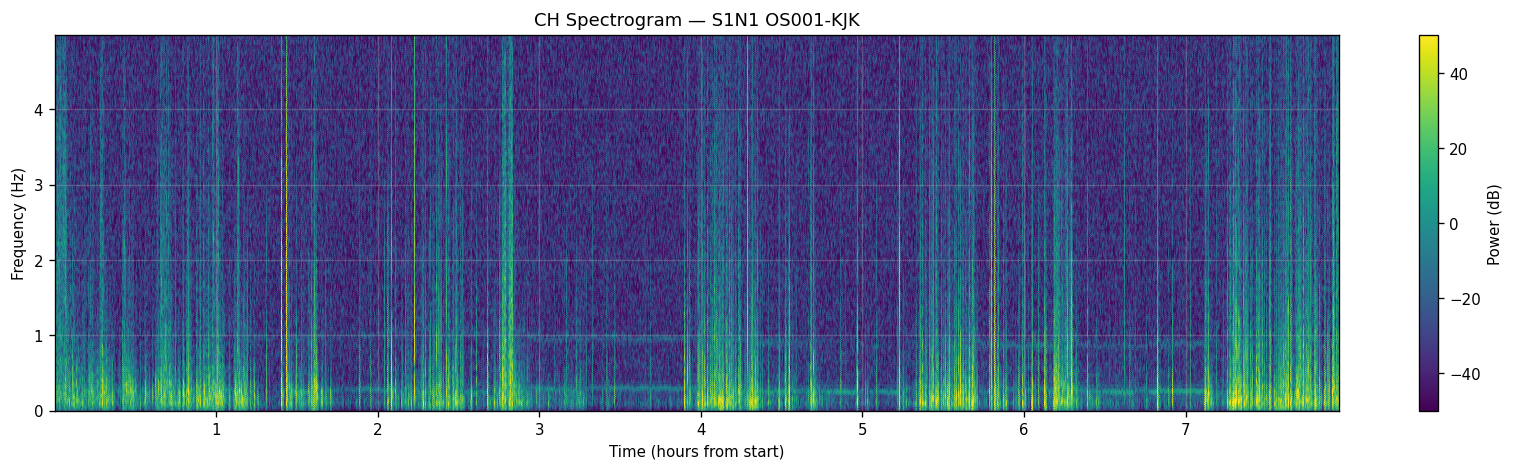

In [9]:
# Cap CH spectrogram (detrended, 0–5 Hz)
s   = sessions[SESSION]
ch  = detrend_segment(s['cap']['CH'], win_sec=10)
t   = s['time_hr']

nperseg  = min(2048, len(ch))
noverlap = min(1800, nperseg - 1)
f_sg, t_sg, Sxx = spectrogram(ch, fs=FS, nperseg=nperseg, noverlap=noverlap, nfft=4096)

f_max   = 5.0
mask_f  = f_sg <= f_max
log_S   = 20 * np.log10(np.abs(Sxx[mask_f, :]) + 1e-12)
t_hr_sg = t_sg / 3600.0

fig, ax = plt.subplots(figsize=(14, 4))
im = ax.pcolormesh(t_hr_sg, f_sg[mask_f], log_S, cmap='viridis', shading='gouraud',
                   vmin=-50, vmax=50)
plt.colorbar(im, ax=ax, label='Power (dB)')
ax.set_ylabel('Frequency (Hz)')
ax.set_xlabel('Time (hours from start)')
m = s['meta']
ax.set_title(f"CH Spectrogram — {m['label']} {m['subject']}-{m['initials']}")
plt.tight_layout(); plt.show()


C:\Users\adity\AppData\Local\Temp\ipykernel_18488\1495039368.py:48: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  powers[band][k] = np.trapz(psd[m], f_w[m])


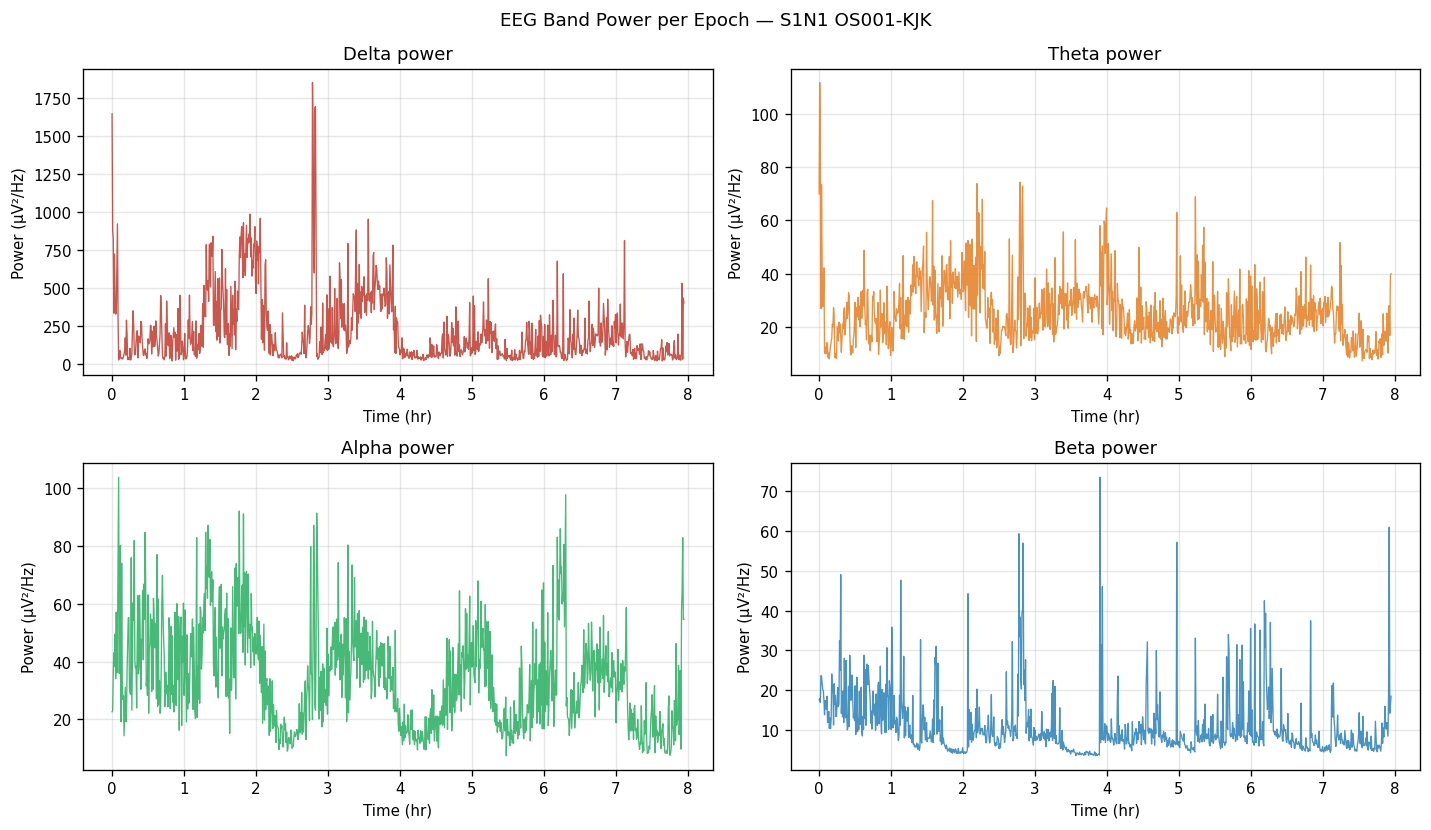

In [10]:
# EEG band power per epoch
s         = sessions[SESSION]
eeg       = s['psg']['EEG'].astype(np.float64)
epoch_sec = 30.0
n_ep      = int(len(eeg) / (epoch_sec * FS))
t_ep      = np.linspace(s['time_hr'][0], s['time_hr'][-1], n_ep)
bp        = compute_band_powers(eeg, FS, t_ep, epoch_sec=epoch_sec)

fig, axes = plt.subplots(2, 2, figsize=(12, 7), sharey=False)
for ax, (band, powers) in zip(axes.flat, bp.items()):
    valid = ~np.isnan(powers)
    ax.plot(t_ep[valid], powers[valid], color=BAND_COLORS[band], lw=0.8, alpha=0.85)
    ax.set_title(f'{band.capitalize()} power')
    ax.set_xlabel('Time (hr)')
    ax.set_ylabel('Power (µV²/Hz)')
m = s['meta']
fig.suptitle(f"EEG Band Power per Epoch — {m['label']} {m['subject']}-{m['initials']}", fontsize=11)
plt.tight_layout(); plt.show()


## Section 7 — Multi-Session Comparison

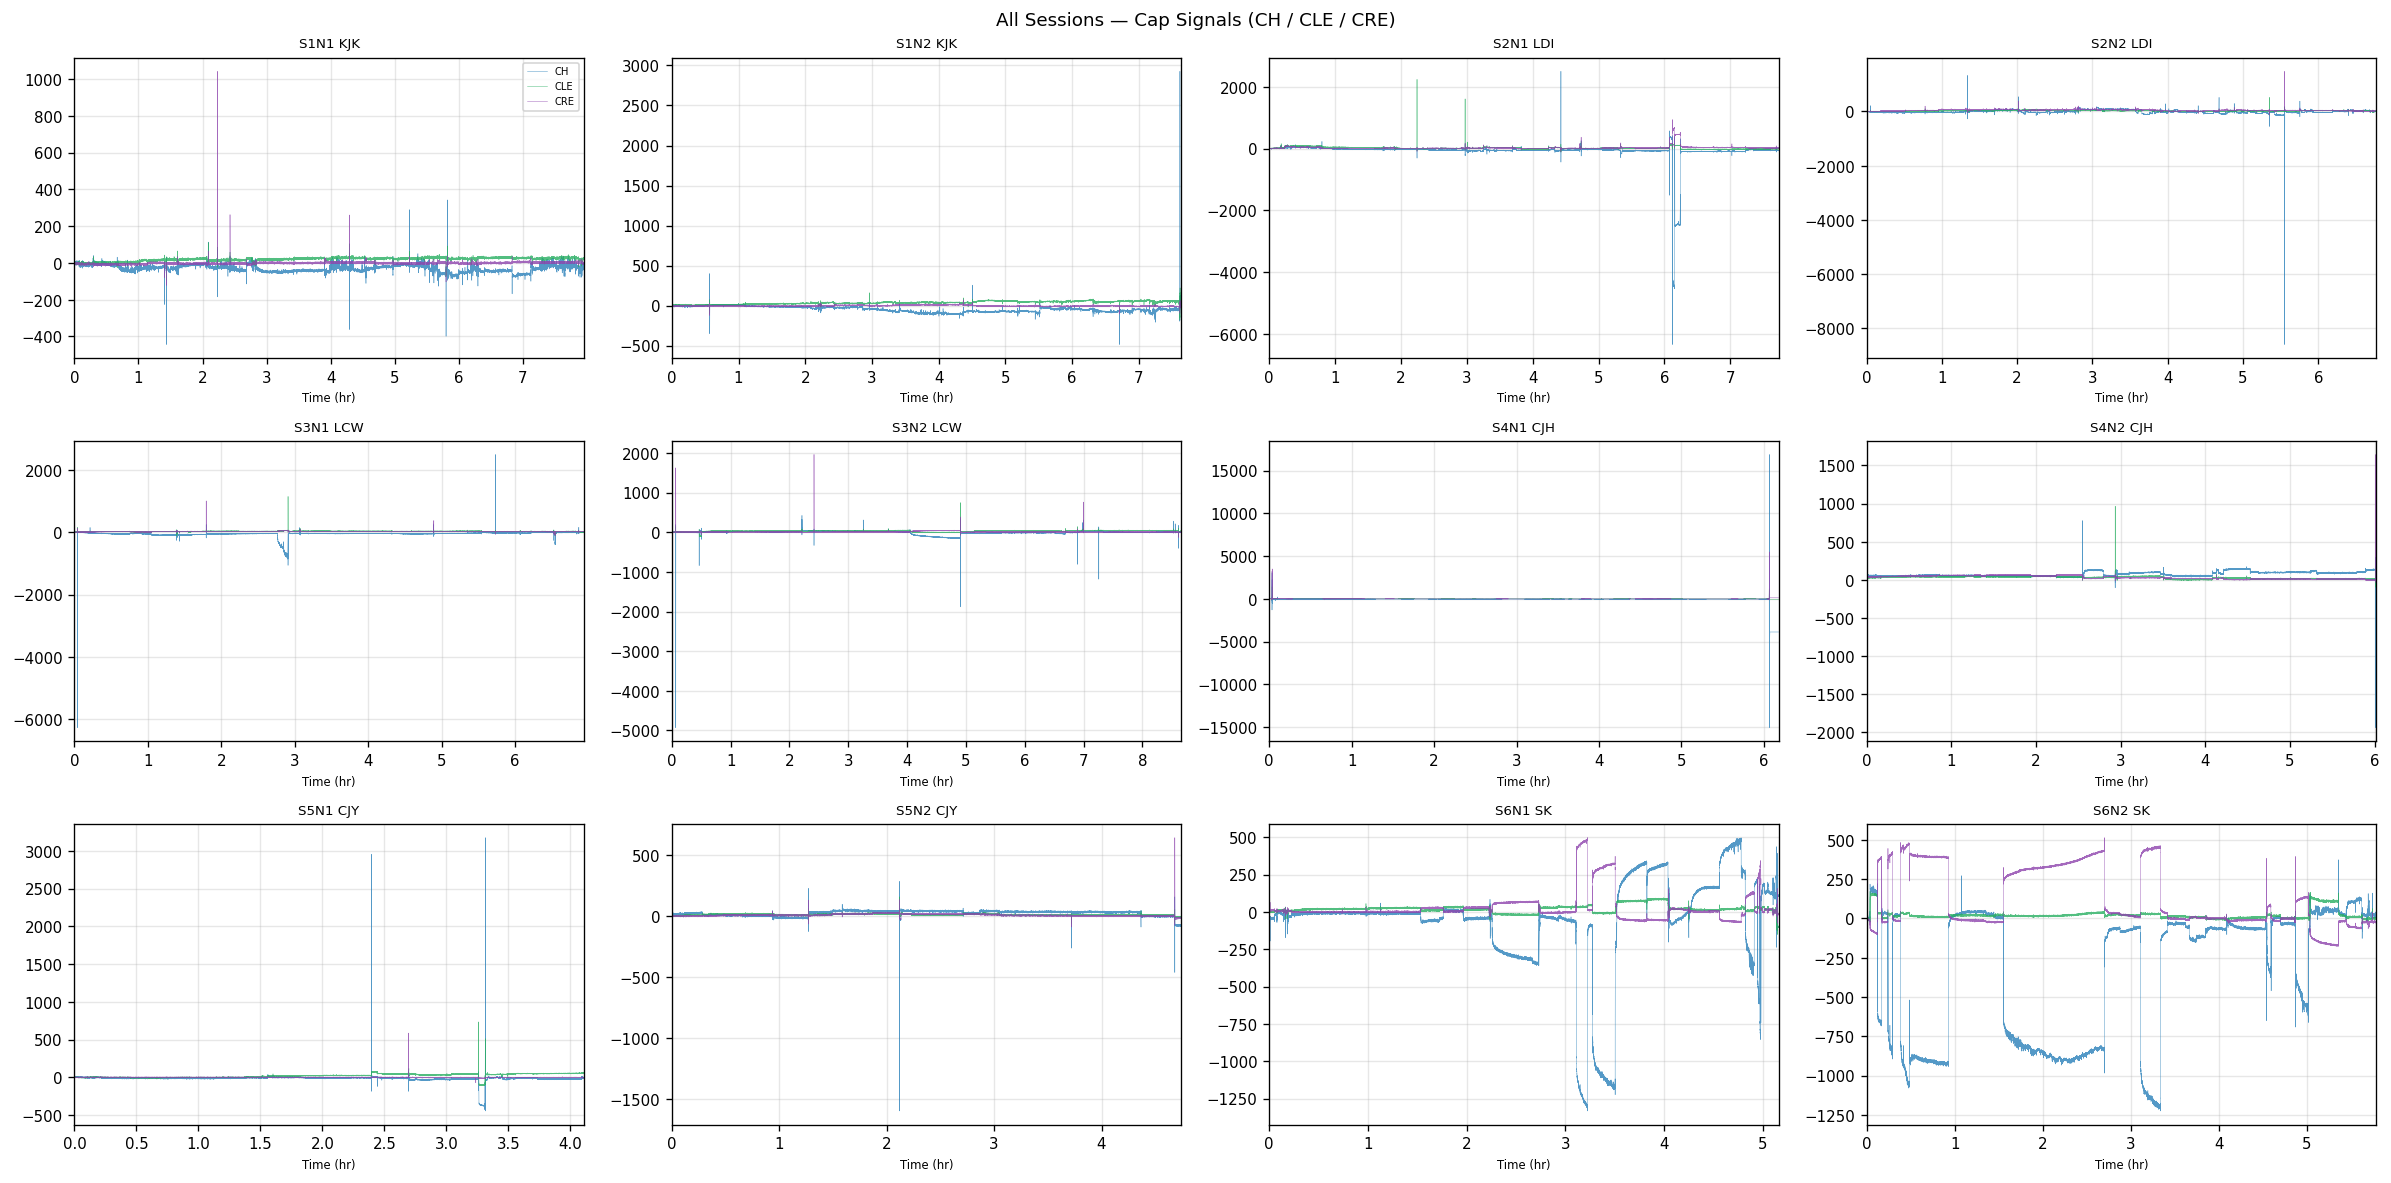

In [11]:
# 3×4 tiled cap overview
fig, axes = plt.subplots(3, 4, figsize=(20, 10), sharey=False)

for ax, s in zip(axes.flat, sessions):
    t   = s['time_hr']
    cap = s['cap']

    CH  = cap['CH']  - cap['CH'][0]
    CLE = cap['CLE'] - cap['CLE'][0]
    CRE = cap['CRE'] - cap['CRE'][0]

    ax.plot(t, CH,  color='#2980B9', lw=0.3, alpha=0.8, label='CH')
    ax.plot(t, CLE, color='#27AE60', lw=0.3, alpha=0.8, label='CLE')
    ax.plot(t, CRE, color='#8E44AD', lw=0.3, alpha=0.8, label='CRE')
    ax.set_xlim(t[0], t[-1])
    m = s['meta']
    ax.set_title(f"{m['label']} {m['initials']}", fontsize=8)
    ax.set_xlabel('Time (hr)', fontsize=7)

axes[0, 0].legend(loc='upper right', fontsize=6)
fig.suptitle('All Sessions — Cap Signals (CH / CLE / CRE)', fontsize=11)
plt.tight_layout(); plt.show()
